# LAB 7 — Visualisasi Interaktif dengan Plotly

**Mata Kuliah:** Analitik dan Visualisasi Data
**Program Studi:** Sistem Informasi — Fakultas Ilmu Komputer
**Universitas Muslim Indonesia**

---

## 1. CPMK dan SubCPMK

**CPMK-1019:** Mampu membuat visualisasi data interaktif menggunakan Python (Plotly) dengan tingkat interaktivitas, user experience, dan fungsionalitas yang baik untuk mendukung eksplorasi data dan pengambilan keputusan berbasis data.

### Sub-CPMK
Setelah praktikum ini mahasiswa mampu:
1. Menggunakan library Plotly (Graph Objects dan Plotly Express)
2. Memilih jenis chart interaktif yang sesuai dengan tipe data
3. Menggunakan **interactive charts** (hover, zoom, pan, selection)
4. Menggunakan **Plotly Express** untuk quick visualizations
5. Membuat **3D visualizations** (3D scatter, surface)
6. Membangun **dashboard interaktif** sederhana dengan Plotly Dash
7. Menerapkan prinsip user experience pada visualisasi interaktif

### Indikator Pencapaian
- ✅ Membuat minimal 5 jenis visualisasi interaktif Plotly
- ✅ Memanfaatkan fitur hover, zoom, pan, filter secara fungsional
- ✅ Membangun mini dashboard menggunakan Plotly Dash
- ✅ Mengekspor visualisasi ke HTML dan static image

---

## 2. Dasar Teori (Ringkas)

### 2.1 Mengapa Visualisasi Interaktif?

Visualisasi statis hanya menampilkan satu sudut pandang. Visualisasi interaktif memungkinkan pengguna:
- **Zoom** ke area tertentu untuk melihat detail
- **Pan** untuk menjelajahi rentang data
- **Hover** untuk informasi spesifik per titik data
- **Filter** dinamis berdasarkan kategori
- **Drill-down** dari level tinggi ke detail

### 2.2 Plotly — Tiga Modul Utama

| Modul | Karakteristik | Use Case |
|-------|---------------|----------|
| `plotly.graph_objects` (go) | Low-level, kontrol penuh | Chart custom kompleks |
| `plotly.express` (px) | High-level, sintaks singkat | EDA cepat, prototipe |
| `dash` | Web framework | Dashboard reaktif |

### 2.3 Keunggulan Plotly vs Matplotlib/Seaborn
1. Interaktivitas bawaan (tidak perlu konfigurasi)
2. Output HTML yang dapat dibagikan
3. Mendukung 3D visualization native
4. Animasi halus untuk time-series
5. Tampilan modern secara default

> **Catatan:** Output Plotly lebih besar karena berisi data + JavaScript untuk interaktivitas. Pertimbangkan ini jika visualisasi akan masuk dokumen statis (PDF).

---

## 3. Instalasi Library

Jalankan sel berikut **sekali saja** jika library belum terinstal. Hapus tanda `#` di awal baris untuk menjalankan instalasi.

In [1]:
# Uncomment baris di bawah jika library belum terinstal
!pip install plotly
!pip install dash
!pip install jupyter-dash
!pip install kaleido  # untuk export ke static image (PNG/JPG/PDF)
!pip install pandas numpy

print("Pastikan semua library sudah terinstal sebelum lanjut ke langkah berikutnya")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.4 MB/s eta 0:00:00
Pastikan semua library sudah terinstal sebelum lanjut ke langkah berikutnya


## 4. Langkah Praktikum

### 4.1 Import Library

In [1]:
import pandas as pd
import numpy as np

# Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Setting tampilan
pd.set_option('display.max_columns', None)

# Setting default template Plotly
pio.templates.default = "plotly_white"

print("Plotly version:", __import__('plotly').__version__)
print("Pandas version:", pd.__version__)
print("Library berhasil diimpor ✓")

Plotly version: 5.24.1
Pandas version: 2.2.2
Library berhasil diimpor ✓


### 4.2 Load Dataset (Olist E-Commerce)

Praktikum ini menggunakan dataset **Olist E-Commerce** (Brazil) yang sudah digunakan pada Lab 6 untuk konsistensi analisis.

**Sumber dataset:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Sesuaikan path di bawah dengan lokasi file CSV di komputer Anda.

In [4]:
# Sesuaikan path dengan lokasi dataset Anda
orders_path = '../dataset/olist_orders_dataset.csv'
items_path = '../dataset/olist_order_items_dataset.csv'
products_path = '../dataset/olist_products_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_items = pd.read_csv(items_path)
df_products = pd.read_csv(products_path)

print("df_orders  :", df_orders.shape)
print("df_items   :", df_items.shape)
print("df_products:", df_products.shape)

NameError: name 'pd' is not defined

### 4.3 Pemeriksaan Awal Dataset

In [ ]:
display(df_orders.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
display(df_items.head())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
display(df_products.head())

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### 4.4 Data Preparation

Beberapa langkah persiapan:
1. **Konversi datetime** — agar dapat diekstrak komponen waktu (bulan, tahun)
2. **Penambahan kolom temporal** — untuk time-series dan animation
3. **Merge dataset** — gabungkan orders, items, dan products
4. **Drop missing values** — pada kolom yang akan divisualisasikan

> Penjelasan setiap langkah penting agar mahasiswa memahami **alasan**, bukan hanya kode.

In [ ]:
# 1. Konversi datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# 2. Tambahkan kolom temporal
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_orders['order_year'] = df_orders['order_purchase_timestamp'].dt.year

# 3. Merge dataset
df = df_orders.merge(df_items, on='order_id', how='inner')
df = df.merge(df_products, on='product_id', how='left')

# 4. Drop missing pada kolom penting untuk visualisasi
df = df.dropna(subset=['product_category_name', 'price', 'freight_value'])

print("Shape data gabungan:", df.shape)
df.head()

Shape data gabungan: (111047, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_year,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,2017,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,2018,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,2018,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,2017,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,2018,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


### 4.5 Pengecekan Missing Values

Pada visualisasi interaktif, missing value dapat menyebabkan hover tidak menampilkan informasi atau menyebabkan error pada animation.

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(10)

order_delivered_customer_date    2388
order_delivered_carrier_date     1157
order_approved_at                  14
product_width_cm                    1
product_height_cm                   1
product_length_cm                   1
product_weight_g                    1
dtype: int64

---

### 4.6 Interactive Scatter Plot dengan Plotly Express

Scatter plot interaktif memungkinkan eksplorasi hubungan dua variabel numerik dengan tambahan informasi melalui **hover**, dimensi tambahan melalui **color** dan **size**, serta eksplorasi area padat melalui **zoom**.

**Fitur interaktif yang diaktifkan:**
- 🖱️ Hover dengan informasi `order_id` dan `product_id`
- 🔍 Zoom & pan (otomatis)
- 🎨 Color mapping per kategori produk
- 📏 Size mapping berdasarkan berat produk

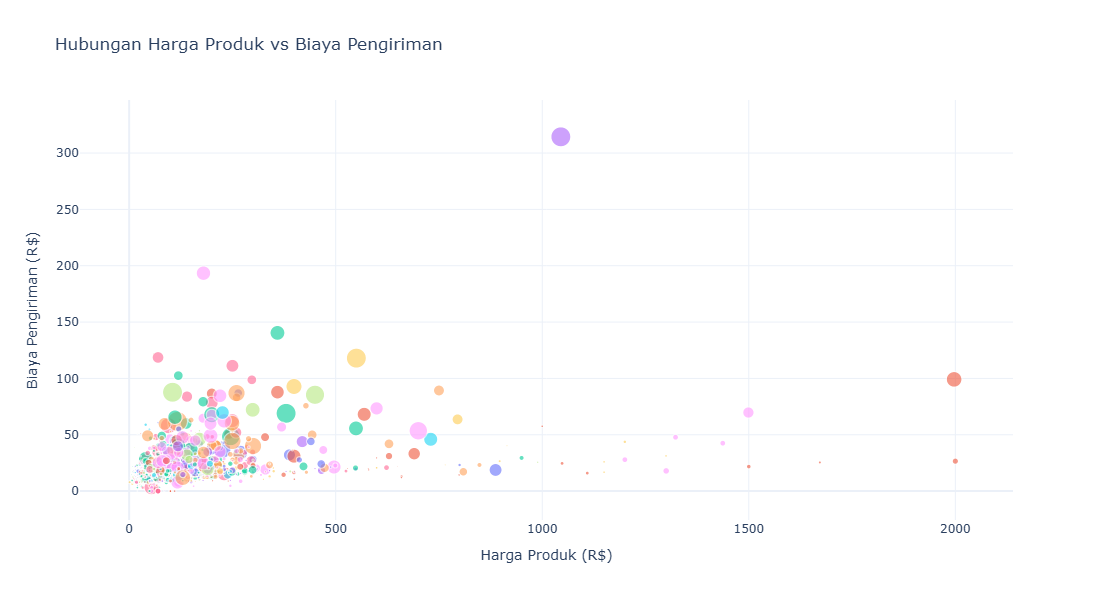

In [ ]:
# Sampling agar visualisasi tidak terlalu padat
df_sample = df.sample(n=2000, random_state=42)

fig = px.scatter(
    df_sample,
    x='price',
    y='freight_value',
    color='product_category_name',
    size='product_weight_g',
    hover_data=['order_id', 'product_id'],
    title='Hubungan Harga Produk vs Biaya Pengiriman',
    labels={
        'price': 'Harga Produk (R$)',
        'freight_value': 'Biaya Pengiriman (R$)'
    },
    opacity=0.6
)

fig.update_layout(
    height=600,
    showlegend=False  # legend disembunyikan karena terlalu banyak kategori
)

fig.show()

**📝 Interpretasi yang diharapkan:**
- Apakah ada hubungan linear antara harga dan biaya pengiriman?
- Bagaimana hover information membantu identifikasi outlier?
- Bagaimana ukuran titik (size) merepresentasikan dimensi tambahan?
- Manfaat zoom untuk fokus pada area dengan kepadatan tinggi?

---

### 4.7 Interactive Line Chart dengan Range Slider

Line chart interaktif sangat berguna untuk **time-series data**. **Range slider** memungkinkan pengguna memilih rentang waktu untuk dianalisis detail.

**Fitur interaktif yang ditambahkan:**
- 📅 Range slider untuk navigasi periode
- 💬 Custom `hovertemplate` dengan format angka rapi
- 🎯 `hovermode='x unified'` untuk menampilkan info semua trace pada x yang sama

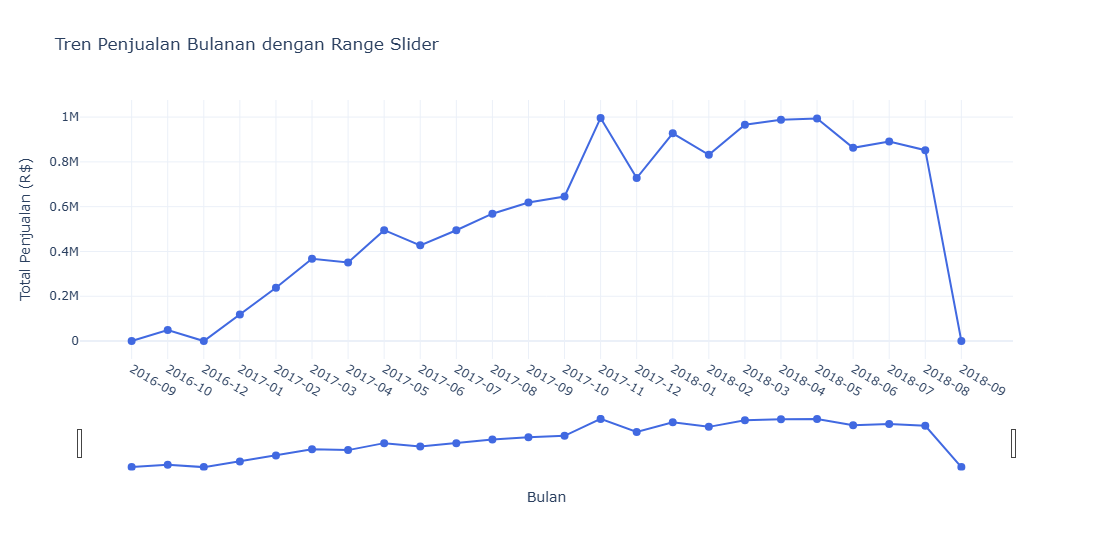

In [ ]:
# Agregasi penjualan bulanan
monthly_sales = (
    df.groupby('order_month')
    .agg(total_sales=('price', 'sum'),
         order_count=('order_id', 'nunique'))
    .reset_index()
    .sort_values('order_month')
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_sales['order_month'],
    y=monthly_sales['total_sales'],
    mode='lines+markers',
    name='Total Penjualan',
    line=dict(color='royalblue', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Bulan:</b> %{x}<br><b>Total Penjualan:</b> R$ %{y:,.2f}<extra></extra>'
))

fig.update_layout(
    title='Tren Penjualan Bulanan dengan Range Slider',
    xaxis=dict(
        title='Bulan',
        rangeslider=dict(visible=True),
        type='category'
    ),
    yaxis_title='Total Penjualan (R$)',
    height=550,
    hovermode='x unified'
)

fig.show()

**📝 Interpretasi yang diharapkan:**
- Pola tren penjualan dari bulan ke bulan
- Apakah ada *seasonal pattern* atau anomali tertentu?
- Bagaimana range slider mempermudah eksplorasi periode tertentu?

---

### 4.8 Interactive Bar Chart dengan Grouping

Bar chart dengan grouping memungkinkan perbandingan multi-dimensi: kategori produk **per tahun**.

**Fitur interaktif:**
- 🏷️ Legend interaktif (klik untuk show/hide kategori)
- 🔍 Zoom pada kategori tertentu
- 💬 Hover untuk nilai eksak

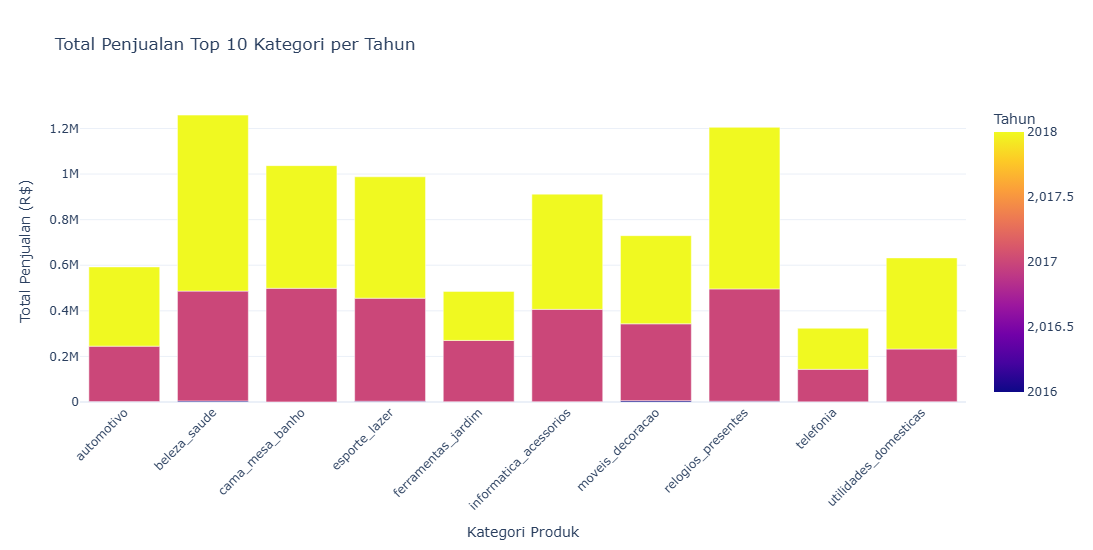

In [ ]:
# Top 10 kategori berdasarkan jumlah penjualan
top_categories = df['product_category_name'].value_counts().head(10).index.tolist()
df_top = df[df['product_category_name'].isin(top_categories)]

# Agregasi per kategori dan tahun
category_year = (
    df_top.groupby(['product_category_name', 'order_year'])
    .agg(total_sales=('price', 'sum'))
    .reset_index()
)

fig = px.bar(
    category_year,
    x='product_category_name',
    y='total_sales',
    color='order_year',
    barmode='group',
    title='Total Penjualan Top 10 Kategori per Tahun',
    labels={
        'total_sales': 'Total Penjualan (R$)',
        'product_category_name': 'Kategori Produk',
        'order_year': 'Tahun'
    }
)

fig.update_layout(height=550, xaxis_tickangle=-45)
fig.show()

**📝 Interpretasi yang diharapkan:**
- Kategori mana yang dominan dari tahun ke tahun?
- Apakah ada pergeseran preferensi pelanggan antar tahun?
- Coba klik salah satu tahun di legend — apa yang terjadi?

---

### 4.9 Interactive Histogram dengan Marginal Boxplot

Histogram interaktif dengan **marginal boxplot** memberikan dua informasi sekaligus: distribusi (histogram) dan summary statistics (boxplot).

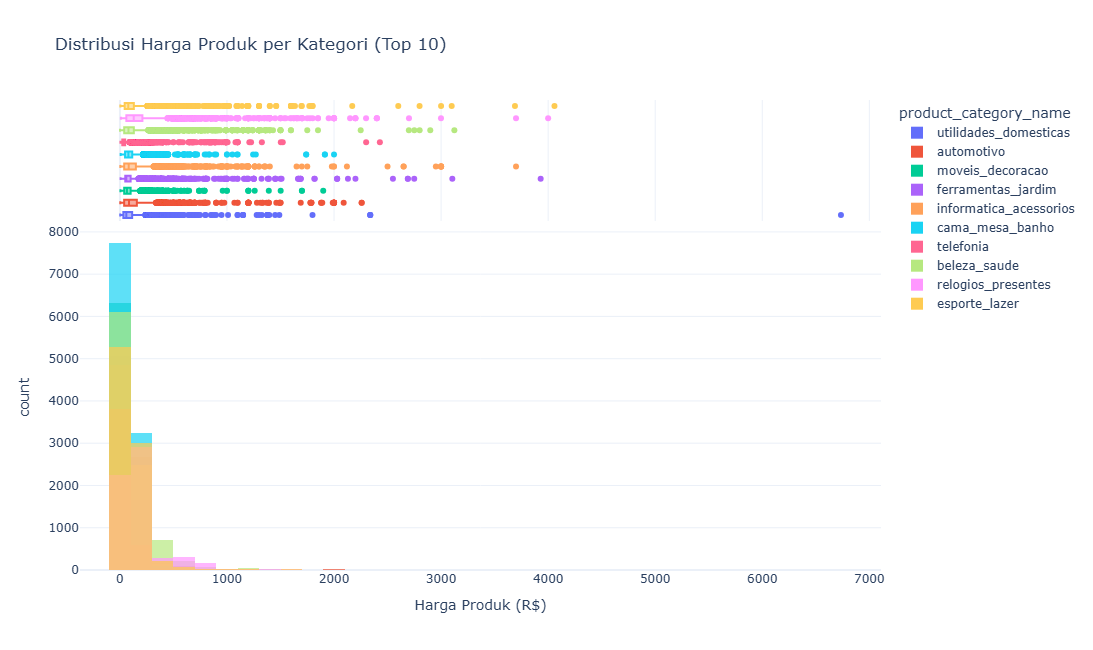

In [ ]:
fig = px.histogram(
    df_top,
    x='price',
    color='product_category_name',
    nbins=50,
    title='Distribusi Harga Produk per Kategori (Top 10)',
    labels={'price': 'Harga Produk (R$)', 'count': 'Frekuensi'},
    opacity=0.7,
    marginal='box'  # menambahkan boxplot di atas histogram
)

fig.update_layout(height=650, barmode='overlay')
fig.show()

**📝 Interpretasi yang diharapkan:**
- Bagaimana distribusi harga berbeda antar kategori?
- Manfaat marginal boxplot untuk informasi tambahan?
- Coba double-click pada salah satu kategori di legend — fitur **isolasi kategori** sangat membantu eksplorasi.

---

### 4.10 3D Scatter Plot

3D scatter plot menampilkan **hubungan tiga variabel numerik** sekaligus dengan kemampuan **rotasi interaktif**.

**Fitur interaktif:**
- 🔄 Drag untuk rotasi 3D
- 🔍 Scroll untuk zoom
- 💬 Hover untuk detail per titik

> ⚠️ **Catatan:** 3D plot tidak selalu lebih baik dari 2D. Gunakan ketika hubungan tiga variabel benar-benar tidak dapat ditampilkan dalam 2D.

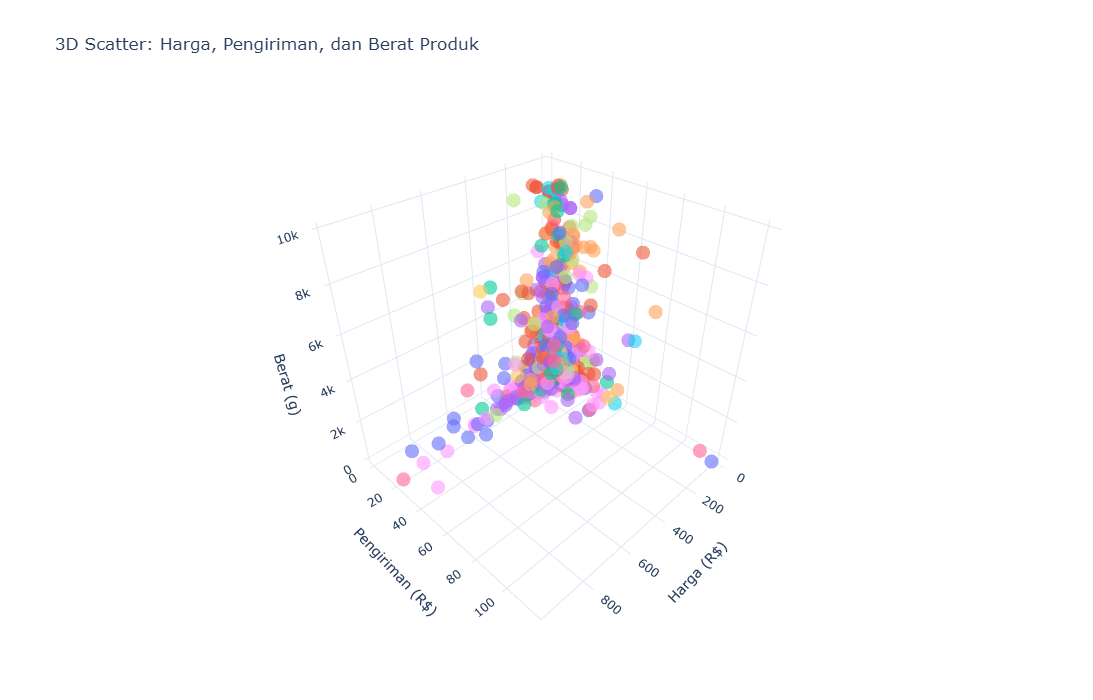

In [ ]:
# Filter agar visualisasi lebih jelas (hilangkan extreme outlier)
df_3d = df.sample(n=1500, random_state=42)
df_3d = df_3d[(df_3d['price'] < 1000) & (df_3d['product_weight_g'] < 10000)]

fig = px.scatter_3d(
    df_3d,
    x='price',
    y='freight_value',
    z='product_weight_g',
    color='product_category_name',
    title='3D Scatter: Harga, Pengiriman, dan Berat Produk',
    labels={
        'price': 'Harga (R$)',
        'freight_value': 'Pengiriman (R$)',
        'product_weight_g': 'Berat (g)'
    },
    opacity=0.6
)

fig.update_layout(height=700, showlegend=False)
fig.show()

**📝 Interpretasi yang diharapkan:**
- Pola hubungan tiga variabel (harga, pengiriman, berat)
- Putar grafik — pola apa yang muncul dari sudut yang berbeda?
- Apa keterbatasan 3D plot dalam membaca posisi titik secara presisi?

---

### 4.11 Subplots — Mini Dashboard dalam Satu Figure

Subplots memungkinkan menampilkan **beberapa visualisasi dalam satu figure** — sangat berguna untuk dashboard sederhana atau perbandingan side-by-side.

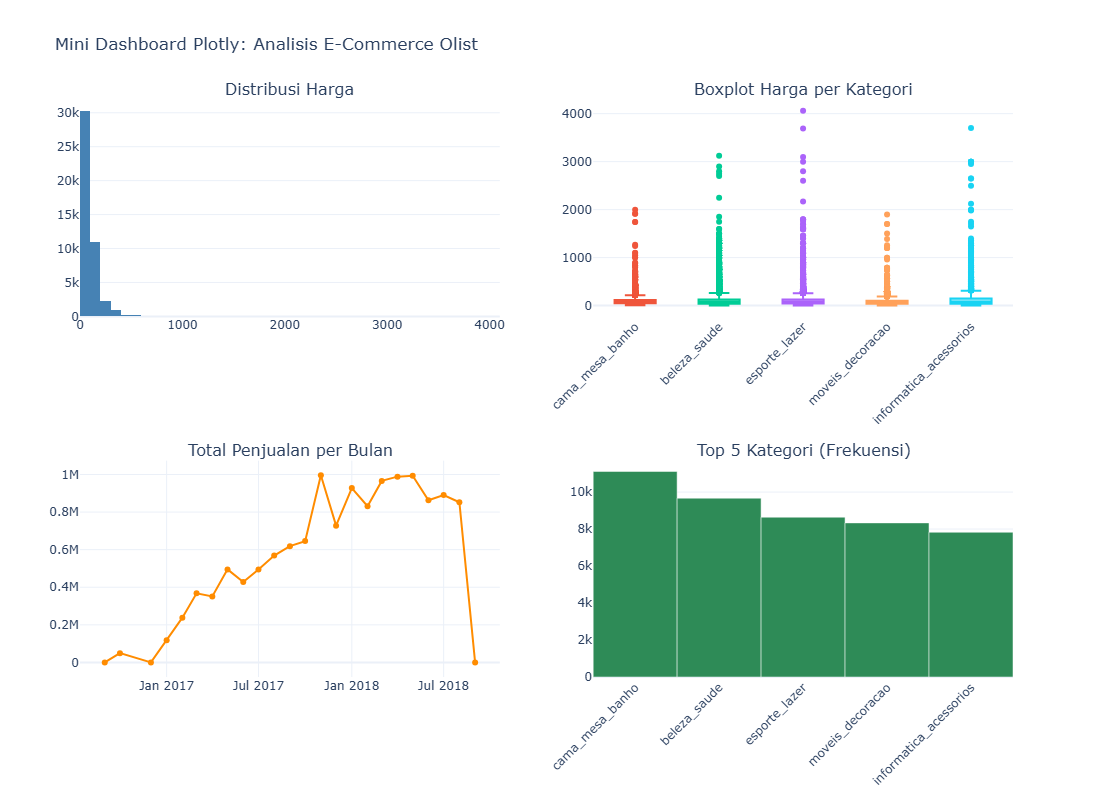

In [ ]:
# Persiapan data
top5_cat = df['product_category_name'].value_counts().head(5).index
df_top5 = df[df['product_category_name'].isin(top5_cat)]

# Buat subplots 2x2
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Distribusi Harga',
        'Boxplot Harga per Kategori',
        'Total Penjualan per Bulan',
        'Top 5 Kategori (Frekuensi)'
    ),
    specs=[[{'type': 'histogram'}, {'type': 'box'}],
           [{'type': 'scatter'},   {'type': 'bar'}]]
)

# Plot 1: Histogram harga
fig.add_trace(
    go.Histogram(x=df_top5['price'], nbinsx=50, name='Harga',
                 marker_color='steelblue'),
    row=1, col=1
)

# Plot 2: Boxplot per kategori
for cat in top5_cat:
    fig.add_trace(
        go.Box(
            y=df_top5[df_top5['product_category_name'] == cat]['price'],
            name=cat,
            showlegend=False
        ),
        row=1, col=2
    )

# Plot 3: Tren penjualan bulanan
fig.add_trace(
    go.Scatter(
        x=monthly_sales['order_month'],
        y=monthly_sales['total_sales'],
        mode='lines+markers',
        name='Penjualan',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)

# Plot 4: Bar chart top 5 kategori
cat_counts = df_top5['product_category_name'].value_counts()
fig.add_trace(
    go.Bar(
        x=cat_counts.index,
        y=cat_counts.values,
        name='Frekuensi',
        marker_color='seagreen'
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text='Mini Dashboard Plotly: Analisis E-Commerce Olist',
    showlegend=False
)

fig.update_xaxes(tickangle=-45, row=2, col=2)
fig.update_xaxes(tickangle=-45, row=1, col=2)

fig.show()

**📝 Interpretasi yang diharapkan:**
- Apa hubungan antar 4 visualisasi tersebut?
- Insight apa yang muncul ketika dilihat bersamaan, yang tidak terlihat jika dilihat satu-satu?
- Bagaimana subplots membantu storytelling data?

---

### 4.12 Animation Plot — Storytelling Time-Series

Animation pada Plotly memungkinkan visualisasi **perubahan data antar waktu**. Sangat efektif untuk presentasi dan storytelling kepada stakeholder.

**Fitur interaktif:**
- ▶️ Play button untuk animasi otomatis
- 🎚️ Slider untuk kontrol manual frame
- 🔍 Tetap dapat zoom/pan/hover saat animasi berjalan

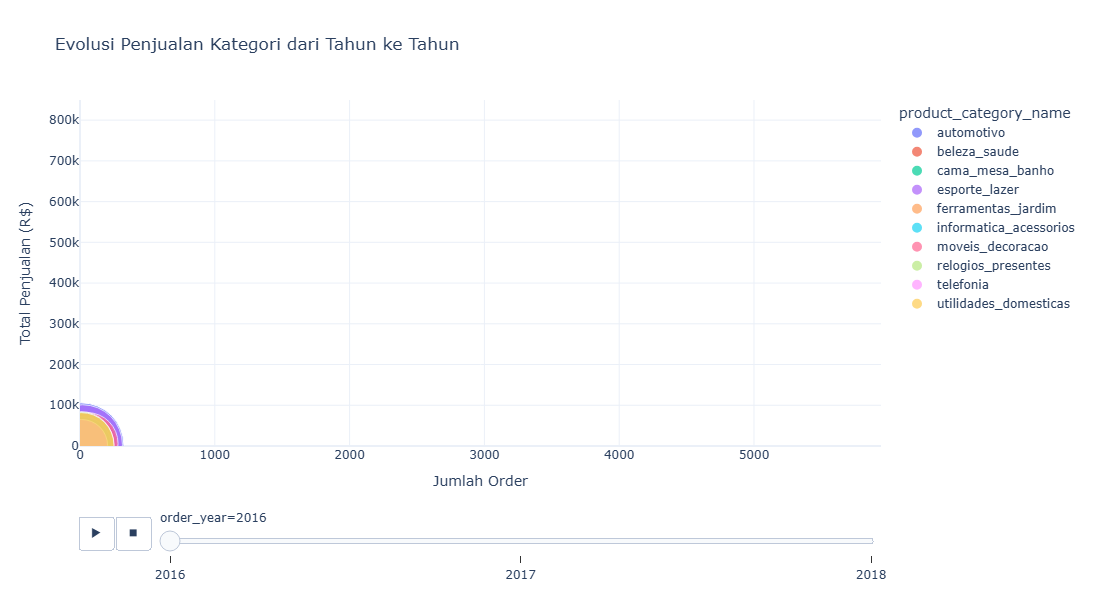

In [ ]:
# Persiapan data: agregasi per kategori dan tahun
animation_data = (
    df_top.groupby(['order_year', 'product_category_name'])
    .agg(
        total_sales=('price', 'sum'),
        order_count=('order_id', 'nunique'),
        avg_freight=('freight_value', 'mean')
    )
    .reset_index()
)

fig = px.scatter(
    animation_data,
    x='order_count',
    y='total_sales',
    size='avg_freight',
    color='product_category_name',
    animation_frame='order_year',
    size_max=60,
    title='Evolusi Penjualan Kategori dari Tahun ke Tahun',
    labels={
        'order_count': 'Jumlah Order',
        'total_sales': 'Total Penjualan (R$)',
        'avg_freight': 'Rata-rata Biaya Pengiriman'
    },
    range_x=[0, animation_data['order_count'].max() * 1.1],
    range_y=[0, animation_data['total_sales'].max() * 1.1]
)

fig.update_layout(height=600)
fig.show()

**📝 Interpretasi yang diharapkan:**
- Bagaimana posisi kategori berubah antar tahun?
- Kategori mana yang menunjukkan pertumbuhan paling signifikan?
- Manfaat animation untuk storytelling vs static plot?

---

### 4.13 Plotly Dash — Dashboard Reaktif

**Plotly Dash** adalah framework Python untuk membangun *web application* interaktif dengan komponen seperti dropdown, slider, dan callback.

**Komponen Dash:**
- `dash.Dash()` — kelas aplikasi utama
- `dash.html` — elemen HTML (Div, H1, P)
- `dash.dcc` — komponen interaktif (Dropdown, Slider, Graph)
- `@app.callback` — decorator untuk fungsi reaktif

> 💡 **Tips:** Untuk Jupyter Notebook, kita gunakan `JupyterDash` (atau `app.run(jupyter_mode='inline')` pada versi terbaru). Jika tidak tersedia, jalankan kode sebagai script Python `.py` terpisah.

In [ ]:
# Cell ini menunjukkan struktur dasar Plotly Dash
# Untuk dijalankan di Jupyter, kita gunakan mode inline / external
# Jika error, jalankan sebagai script .py di terminal

try:
    from dash import Dash, dcc, html, Input, Output

    app = Dash(__name__)

    # Layout dashboard
    app.layout = html.Div([
        html.H1(
            'Dashboard Penjualan E-Commerce Olist',
            style={'textAlign': 'center', 'color': '#1F3864'}
        ),

        html.Div([
            html.Label('Pilih Kategori Produk:',
                       style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='category-dropdown',
                options=[{'label': cat, 'value': cat} for cat in top_categories],
                value=top_categories[0],
                clearable=False
            ),
        ], style={'width': '60%', 'margin': '20px auto'}),

        html.Div([
            html.Label('Rentang Harga (R$):',
                       style={'fontWeight': 'bold'}),
            dcc.RangeSlider(
                id='price-range',
                min=0,
                max=1000,
                step=50,
                value=[0, 500],
                marks={i: f'R${i}' for i in range(0, 1001, 200)}
            ),
        ], style={'width': '80%', 'margin': '20px auto'}),

        dcc.Graph(id='price-distribution'),
        dcc.Graph(id='sales-trend')
    ])

    # Callback: update grafik berdasarkan input
    @app.callback(
        [Output('price-distribution', 'figure'),
         Output('sales-trend', 'figure')],
        [Input('category-dropdown', 'value'),
         Input('price-range', 'value')]
    )
    def update_graphs(selected_category, price_range):
        filtered = df[
            (df['product_category_name'] == selected_category) &
            (df['price'].between(price_range[0], price_range[1]))
        ]

        # Histogram distribusi harga
        fig1 = px.histogram(
            filtered, x='price', nbins=40,
            title=f'Distribusi Harga - {selected_category} '
                  f'(R${price_range[0]}-R${price_range[1]})'
        )

        # Tren bulanan
        monthly = (filtered.groupby('order_month')['price']
                          .sum().reset_index())
        fig2 = px.line(
            monthly, x='order_month', y='price',
            title=f'Tren Penjualan Bulanan - {selected_category}',
            markers=True
        )
        fig2.update_layout(xaxis_tickangle=-45)

        return fig1, fig2

    print("✓ Aplikasi Dash berhasil didefinisikan.")
    print("  Untuk menjalankan, gunakan salah satu cara berikut:")
    print("  1. Jupyter (versi baru): app.run(jupyter_mode='inline', port=8050)")
    print("  2. Jupyter (lama)       : app.run_server(mode='inline', port=8050)")
    print("  3. Terminal             : python nama_file.py")

except ImportError as e:
    print("Library Dash belum terinstal.")
    print("Jalankan: pip install dash")
    print(f"Error: {e}")

✓ Aplikasi Dash berhasil didefinisikan.
  Untuk menjalankan, gunakan salah satu cara berikut:
  1. Jupyter (versi baru): app.run(jupyter_mode='inline', port=8050)
  2. Jupyter (lama)       : app.run_server(mode='inline', port=8050)
  3. Terminal             : python nama_file.py


In [ ]:
# Jalankan aplikasi Dash (uncomment salah satu sesuai versi Anda)

# === Versi Dash terbaru (2.11+) ===
app.run(jupyter_mode='inline', port=8050, debug=False)

# === Versi lama (gunakan jupyter-dash) ===
app.run_server(mode='inline', port=8050, debug=False)

# === Standalone (di luar Jupyter) ===
if __name__ == '__main__':
    app.run(debug=True, port=8050)

print("Buka http://127.0.0.1:8050 di browser jika dijalankan sebagai script")

ObsoleteAttributeException: app.run_server has been replaced by app.run

---

### 4.14 Export Visualisasi

Plotly visualization dapat diekspor ke berbagai format:
- **HTML** — interaktif, dapat dibuka di browser
- **PNG / JPG / PDF / SVG** — static image (perlu library `kaleido`)

In [ ]:
# Buat satu figure untuk dieksport
fig_export = px.scatter(
    df_sample,
    x='price', y='freight_value',
    color='product_category_name',
    title='Demo Export: Harga vs Pengiriman',
    opacity=0.5
)
fig_export.update_layout(showlegend=False, height=500)

# Export ke HTML (interaktif)
fig_export.write_html('output_visualisasi_interaktif.html')
print("✓ HTML berhasil disimpan: output_visualisasi_interaktif.html")

# Export ke static image (uncomment jika kaleido sudah terinstal)
# fig_export.write_image('output_visualisasi.png', width=1200, height=600)
# fig_export.write_image('output_visualisasi.pdf')
# print('✓ Static image berhasil disimpan')

✓ HTML berhasil disimpan: output_visualisasi_interaktif.html


---

### 4.15 Rangkuman: Pemilihan Plot Berdasarkan Tujuan

| Plot | Use Case | Kelebihan Versi Interaktif |
|------|----------|---------------------------|
| Scatter plot | Hubungan 2 variabel | Hover, zoom outlier, color/size mapping |
| Line + range slider | Time-series | Eksplorasi periode fleksibel |
| Bar (grouped/stacked) | Perbandingan kategori | Legend filter, hover nilai eksak |
| Histogram + marginal | Distribusi numerik | Isolasi kategori, summary stats |
| 3D scatter | 3 variabel sekaligus | Rotasi multi-sudut |
| Subplots | Dashboard sederhana | Multi-perspektif dalam 1 figure |
| Animation | Storytelling temporal | Play/pause, slider frame |
| Plotly Dash | Tools eksplorasi reaktif | Dropdown, slider, callback |

> 💡 Mahasiswa harus memahami: **satu jenis plot tidak bisa dipakai untuk semua situasi**. Pemilihan yang tepat menghasilkan insight yang lebih bermakna.

---

## 5. Hasil dan Pembahasan

> 📝 **Petunjuk pengisian:** Setelah menjalankan seluruh kode di atas, lengkapi bagian ini dengan observasi, analisis, insight, dan implikasi bisnis berdasarkan visualisasi Anda sendiri.

### 5.1 Interactive Scatter Plot — Eksplorasi Hubungan Variabel

**Observasi:**
> _(Tuliskan apa yang Anda lihat: pola data, konsentrasi titik, outlier yang ditemukan via hover, dst.)_

**Analisis:**
> _(Jelaskan mengapa pola tersebut muncul: hubungan harga vs pengiriman dipengaruhi apa? Apakah pola sesuai ekspektasi bisnis?)_

**Insight:**
- Insight 1: ...
- Insight 2: ...
- Insight 3: ...

**Implikasi Bisnis:**
- Implikasi 1: ...
- Implikasi 2: ...

---

### 5.2 Interactive Line Chart — Analisis Time-Series

**Observasi:**
> _(Pola tren bulanan, periode lonjakan, periode penurunan, dst.)_

**Analisis:**
> _(Apa penyebab pola tersebut? Adakah event khusus, pertumbuhan organik, atau seasonal pattern?)_

**Insight:**
- ...

**Implikasi Bisnis:**
- ...

---

### 5.3 Interactive Bar Chart — Perbandingan Multi-Dimensi

**Observasi:**
> _(Kategori dominan, perbedaan antar tahun, dst.)_

**Analisis:**
> _(Mengapa terjadi pergeseran? Kategori mana yang growing, mana yang shrinking?)_

**Insight:**
- ...

**Implikasi Bisnis:**
- ...

---

### 5.4 3D Scatter Plot — Multi-Variable Exploration

**Observasi:**
> _(Pola 3D, pola yang muncul dari sudut tertentu, dst.)_

**Analisis:**
> _(Apakah 3D memberi informasi tambahan dibanding 2D? Variabel mana yang dominan?)_

**Insight:**
- ...

**Keterbatasan yang ditemui:**
- ...

---

### 5.5 Subplots & Animation — Dashboard Storytelling

**Observasi:**
> _(Bagaimana 4 visualisasi saling melengkapi? Animasi mengungkap pola apa?)_

**Analisis:**
> _(Sintesis insight dari kombinasi visualisasi)_

**Insight:**
- ...

---

### Sintesis Insight (Integrasi Semua Visualisasi)

> _(Tuliskan kesimpulan terpadu: pola besar yang muncul ketika seluruh visualisasi digabungkan)_

### Kesimpulan Analitik

> _(Refleksi: apa keunggulan visualisasi interaktif dibanding statis dalam analisis ini?)_

---

## 6. Soal Praktikum

**Instruksi Umum:** Gunakan dataset Olist E-Commerce. Setiap jawaban WAJIB mencakup: **kode visualisasi**, **hasil grafik**, **interpretasi** (observasi + analisis + insight), dan **penjelasan fitur interaktif** yang digunakan.

---

### 📌 Soal 1 — Interactive Scatter Plot

Buat interactive scatter plot menggunakan Plotly Express dengan:
- `price` di sumbu x
- `freight_value` di sumbu y
- `product_category_name` sebagai color
- `product_weight_g` sebagai size

**Pertanyaan:**
1. Apa hubungan yang terlihat antara harga dan biaya pengiriman?
2. Bagaimana hover information membantu eksplorasi data?
3. Bagaimana fungsi zoom membantu identifikasi pola pada area padat?
4. Insight apa yang muncul ketika kategori difilter melalui legend?

In [ ]:
# === JAWABAN SOAL 1 ===
# Tuliskan kode Anda di sini



**Interpretasi Soal 1:**

> _(Tuliskan observasi, analisis, dan insight Anda di sini)_

---

### 📌 Soal 2 — Interactive Line Chart dengan Range Slider

Buat line chart interaktif untuk:
- Total penjualan bulanan
- Tambahkan range slider
- Customize hovertemplate dengan format angka dan tanggal

**Pertanyaan:**
1. Bagaimana pola tren penjualan dari waktu ke waktu?
2. Apakah ada periode dengan anomali (lonjakan atau penurunan)?
3. Bagaimana range slider membantu analisis multi-periode?
4. Apa keunggulan hovertemplate custom dibandingkan default?

In [ ]:
# === JAWABAN SOAL 2 ===



**Interpretasi Soal 2:**

> _(Tuliskan jawaban Anda di sini)_

---

### 📌 Soal 3 — Interactive Bar Chart dengan Grouping

Buat bar chart interaktif untuk:
- Top 10 kategori produk
- Total penjualan per tahun (grouping)
- Eksplorasi `barmode='group'` dan `barmode='stack'`

**Pertanyaan:**
1. Kategori mana yang paling dominan?
2. Apakah ada pergeseran tren antar tahun?
3. Apa perbedaan insight antara `barmode='group'` vs `barmode='stack'`?
4. Bagaimana legend interaktif mempermudah analisis?

In [ ]:
# === JAWABAN SOAL 3 ===



**Interpretasi Soal 3:**

> _(Tuliskan jawaban Anda)_

---

### 📌 Soal 4 — 3D Scatter Plot

Buat 3D scatter plot untuk variabel:
- `price`, `freight_value`, `product_weight_g`
- Color berdasarkan kategori produk

**Pertanyaan:**
1. Pola apa yang terlihat ketika ketiga variabel divisualisasikan bersamaan?
2. Bagaimana rotasi 3D membantu identifikasi pola?
3. Apa keterbatasan 3D plot dibandingkan 2D scatter?
4. Kapan sebaiknya menggunakan 3D plot dan kapan tidak?

In [ ]:
# === JAWABAN SOAL 4 ===



**Interpretasi Soal 4:**

> _(Tuliskan jawaban Anda)_

---

### 📌 Soal 5 — Subplots Dashboard

Buat subplots **2x2** dengan 4 visualisasi berbeda:
1. Histogram distribusi harga
2. Boxplot harga per kategori (top 5)
3. Line chart tren penjualan
4. Bar chart top kategori

**Pertanyaan:**
1. Apa hubungan antar 4 visualisasi tersebut?
2. Insight apa yang muncul ketika dilihat secara bersamaan?
3. Bagaimana subplots membantu storytelling data?
4. Apa keunggulan dan keterbatasan subplots?

In [ ]:
# === JAWABAN SOAL 5 ===



**Interpretasi Soal 5:**

> _(Tuliskan jawaban Anda)_

---

### 📌 Soal 6 — Animation Plot

Buat scatter plot dengan animation untuk:
- Total penjualan vs jumlah order per kategori
- `animation_frame` berdasarkan tahun
- Size berdasarkan rata-rata biaya pengiriman

**Pertanyaan:**
1. Bagaimana posisi kategori berubah antar tahun?
2. Kategori mana yang menunjukkan pertumbuhan paling signifikan?
3. Apa keunggulan animation untuk storytelling data?
4. Kapan animation tidak cocok digunakan?

In [ ]:
# === JAWABAN SOAL 6 ===



**Interpretasi Soal 6:**

> _(Tuliskan jawaban Anda)_

---

### 📌 Soal 7 — Plotly Dash Mini Dashboard

Buat dashboard sederhana menggunakan Plotly Dash dengan minimal:
- 1 dropdown untuk filter kategori produk
- 1 slider/RangeSlider untuk filter rentang harga
- 2 visualisasi yang reaktif terhadap input pengguna

**Pertanyaan:**
1. Bagaimana mekanisme callback bekerja dalam Dash?
2. Apa keunggulan Dash dibandingkan visualisasi standalone?
3. Bagaimana dashboard interaktif membantu stakeholder non-teknis?
4. Apa tantangan dalam membuat dashboard yang user-friendly?

In [ ]:
# === JAWABAN SOAL 7 ===



**Interpretasi Soal 7:**

> _(Tuliskan jawaban Anda)_

---

### 📌 Soal 8 — Evaluasi dan Perbandingan (Critical Thinking)

Untuk setiap jenis visualisasi berikut, jelaskan secara tertulis (tidak perlu kode):
- **Kapan digunakan**
- **Kapan TIDAK boleh digunakan**
- **Keunggulan versi interaktif** dibandingkan statis

Plot yang dievaluasi:
- Scatter plot interaktif
- Line chart dengan range slider
- Bar chart dengan grouping
- 3D scatter plot
- Animation plot
- Dashboard Plotly Dash

**Pertanyaan tambahan:**
1. Apa kesalahan paling umum dalam pembuatan visualisasi interaktif?
2. Berikan contoh **misuse** interaktivitas dan dampaknya terhadap interpretasi.

**Jawaban Soal 8:**

| Plot | Kapan digunakan | Kapan TIDAK boleh | Keunggulan versi interaktif |
|------|-----------------|-------------------|------------------------------|
| Scatter plot interaktif | _(isi)_ | _(isi)_ | _(isi)_ |
| Line + range slider | _(isi)_ | _(isi)_ | _(isi)_ |
| Bar grouping | _(isi)_ | _(isi)_ | _(isi)_ |
| 3D scatter | _(isi)_ | _(isi)_ | _(isi)_ |
| Animation | _(isi)_ | _(isi)_ | _(isi)_ |
| Dashboard Dash | _(isi)_ | _(isi)_ | _(isi)_ |

**Kesalahan umum & misuse:**
> _(Tuliskan analisis Anda)_

---

## 7. Kesimpulan & Refleksi

> _(Setelah menyelesaikan seluruh praktikum, tuliskan refleksi pembelajaran Anda)_

**Pembelajaran utama:**
1. ...
2. ...
3. ...

**Tantangan yang dihadapi:**
- ...

**Saran pengembangan:**
- ...

---

## 📚 Referensi

1. Plotly Python — https://plotly.com/python/
2. Plotly Express — https://plotly.com/python/plotly-express/
3. Plotly Dash — https://dash.plotly.com/
4. AI Publishing, *Python Data Visualization Essentials Guide*, BPB Publications, 2024.
5. Nexus AI, *Python for Data Visualization: Creating Insightful Visuals with Matplotlib, Seaborn, and Plotly*, 2024.

---

**Selesai — Lab 7: Visualisasi Interaktif dengan Plotly** ✨
